In [62]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load the JSON responses
with open('/home/ubuntu/Multimodal-Uncertainty-Quantification/llava_mmt_output_uq_io_graph_similarity.json', 'r') as file:
# with open('/home/ubuntu/Multimodal-Uncertainty-Quantification/llava_mmt_output_uq_io_graph_similarity.json1', 'r') as file:
    responses_with_uncertainty = json.load(file)

# Load the DataFrame with correct answers
df = pd.read_csv('/home/ubuntu/Multimodal-Uncertainty-Quantification/datasets_/MMT-Bench/MMT-Bench_VAL.tsv', sep='\t')
df = df[df['category'].str.contains('hallucination')]

# # Extract the answers from the DataFrame
true_answers = dict(zip(range(2787,2866), df['answer']))


In [63]:
# uncertainties

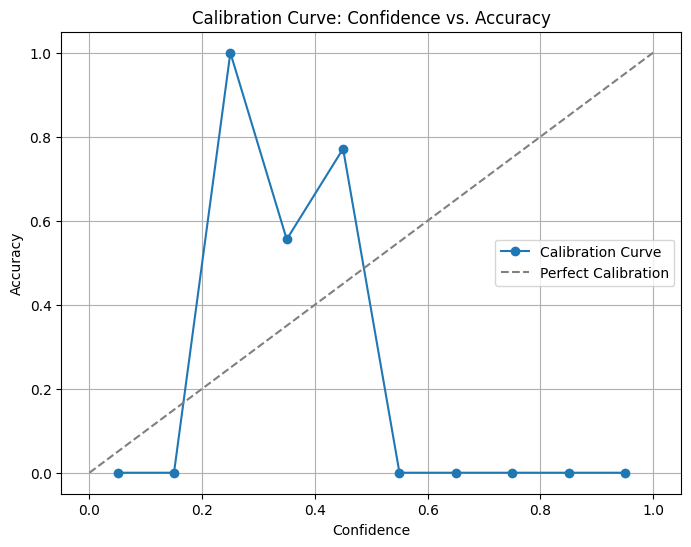

In [64]:
# import json
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt

# # Load the JSON responses
# with open('/home/ubuntu/Multimodal-Uncertainty-Quantification/llava_mmt_output1_uq_io.json', 'r') as file:
#     responses_with_uncertainty = json.load(file)

# # Load the DataFrame with correct answers
# df = pd.read_csv('/home/ubuntu/Multimodal-Uncertainty-Quantification/datasets/MMT-Bench/MMT-Bench_VAL.tsv', sep='\t')

# # Extract the answers from the DataFrame using the 'index' column as keys
# true_answers = dict(zip(df['index'].astype(str), df['answer']))

# Initialize lists to store uncertainties and accuracies
uncertainties = []
accuracies = []

# Extract data from responses_with_uncertainty
for idx, result in responses_with_uncertainty.items():
    responses = result['responses']
    uncertainty = result['uncertainty']
    true_answer = true_answers.get(int(idx))
    # print(true_answer)
    # Calculate if the model's answer is correct
    correct = any(response['answer'] == true_answer for response in responses)
    
    # Append the data to lists
    uncertainties.append(uncertainty)
    accuracies.append(int(correct))

# Convert lists to NumPy arrays and convert nans to average uncertainty
uncertainties = np.array(uncertainties)

# remove nans
uncertainties_copy = uncertainties.copy()
uncertainties = uncertainties[~np.isnan(uncertainties_copy)]
accuracies = np.array(accuracies)[~np.isnan(uncertainties_copy)]
# uncertainties = 1 - uncertainties  # Convert uncertainty to confidence



# Bin data by uncertainty
def bin_data(uncertainties, accuracies, num_bins=10):
    bins = np.linspace(0, 1, num_bins + 1)
    bin_indices = np.digitize(uncertainties, bins) - 1

    bin_centers = (bins[:-1] + bins[1:]) / 2  # Calculate bin centers for plotting
    bin_accuracies = []

    for i in range(num_bins):
        bin_mask = bin_indices == i
        if np.any(bin_mask):
            bin_accuracies.append(np.mean(accuracies[bin_mask]))
        else:
            bin_accuracies.append(0)  # If no data points fall in the bin, set accuracy to 0

    return bin_centers, bin_accuracies

# Plot the calibration curve
def plot_calibration_curve(uncertainties, accuracies, num_bins=10):
    bin_centers, bin_accuracies = bin_data(uncertainties, accuracies, num_bins)
    
    plt.figure(figsize=(8, 6))
    plt.plot(bin_centers, bin_accuracies, marker='o', label='Calibration Curve')
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect Calibration')
    plt.xlabel('Confidence')
    plt.ylabel('Accuracy')
    plt.title('Calibration Curve: Confidence vs. Accuracy')
    plt.legend()
    plt.grid(True)
    plt.show()

# Plot the calibration curve
plot_calibration_curve(uncertainties, accuracies, num_bins=10)


Text(0, 0.5, 'Number of Samples')

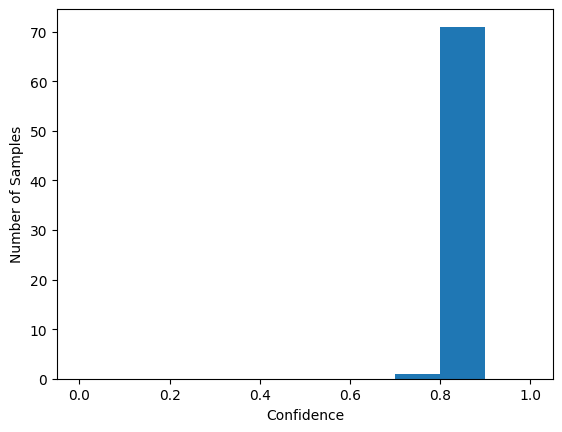

In [57]:
plt.hist(uncertainties, bins=np.linspace(0, 1, 11))
plt.xlabel('Confidence')
plt.ylabel('Number of Samples')

Text(0, 0.5, 'Number of Samples')

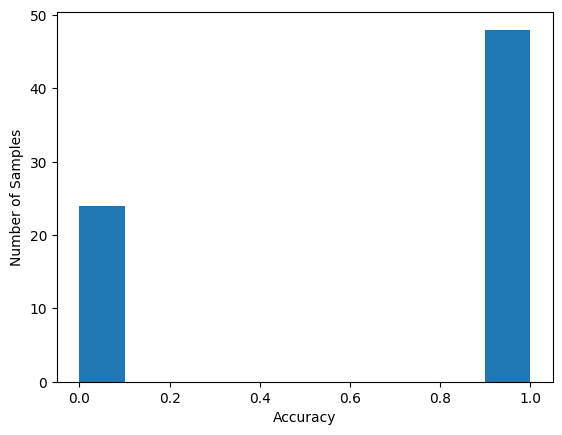

In [58]:
plt.hist(accuracies, bins=np.linspace(0, 1, 11))
plt.xlabel('Accuracy')
plt.ylabel('Number of Samples')

In [49]:
uncertainties

array([0.40493173, 0.38728228, 0.42074758, 0.41719398, 0.37239126,
       0.4099784 , 0.34416962, 0.38710076, 0.39530566, 0.38463774,
       0.3993118 , 0.42576416, 0.40913599, 0.38680698, 0.41202509,
       0.39469158, 0.38720474, 0.3992214 , 0.37329224, 0.40545293,
       0.41076783, 0.42178516, 0.3954395 , 0.40448354, 0.41542635,
       0.39513507, 0.40562847, 0.40804228, 0.39330963, 0.36877499,
       0.41831625, 0.39781023, 0.40234694, 0.39152764, 0.41060944,
       0.37464637, 0.39883172, 0.4077947 , 0.40501411, 0.4131415 ,
       0.40813193, 0.41574315, 0.4637966 , 0.42951703, 0.39319028,
       0.38916421, 0.40495794, 0.40394904, 0.39606289, 0.41681107,
       0.35279754, 0.42558695, 0.40054936, 0.41724364, 0.41999845,
       0.38243965, 0.250363  , 0.40499766, 0.41833383, 0.38646369,
       0.38602917, 0.38972707, 0.39253295, 0.37022102, 0.38108064,
       0.37980214, 0.38049517, 0.41591487, 0.40342039, 0.35192682,
       0.39941262, 0.38440771])

In [23]:
# replace nan with 1
uncertainties = np.nan_to_num(uncertainties, nan=1.0)

In [42]:
1 - uncertainties

array([0.59506827, 0.61271772, 0.57925242, 0.58280602, 0.62760874,
       0.5900216 , 0.65583038, 0.61289924, 0.60469434, 0.61536226,
       0.6006882 , 0.57423584, 0.59086401, 0.61319302, 0.58797491,
       0.60530842, 0.61279526, 0.6007786 , 0.62670776, 0.59454707,
       0.58923217, 0.57821484, 0.6045605 , 0.59551646, 0.58457365,
       0.60486493, 0.59437153, 0.59195772, 0.60669037, 0.63122501,
       0.58168375, 0.60218977, 0.59765306, 0.60847236, 0.58939056,
       0.60318686, 0.62535363, 0.60116828, 0.5922053 , 0.59498589,
       0.5868585 , 0.59186807, 0.58425685, 0.5362034 , 0.57048297,
       0.60680972, 0.61083579, 0.59504206, 0.59605096, 0.60393711,
       0.58318893, 0.64720246, 0.57441305, 0.59945064, 0.58275636,
       0.58000155, 0.61756035, 0.749637  , 0.59500234, 0.58166617,
       0.61353631, 0.60318686, 0.60318686, 0.61397083, 0.61027293,
       0.60746705, 0.62977898, 0.60318686, 0.60318686, 0.61891936,
       0.62019786, 0.60318686, 0.60318686, 0.61950483, 0.60318